## Supplementary plots brain
- Modality contributions
- Scree plot

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [4]:
cfs_path="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg"

eigs = np.loadtxt(os.path.join(cfs_path, "eigenvalues_percent"))

print(eigs.shape)


(11372,)


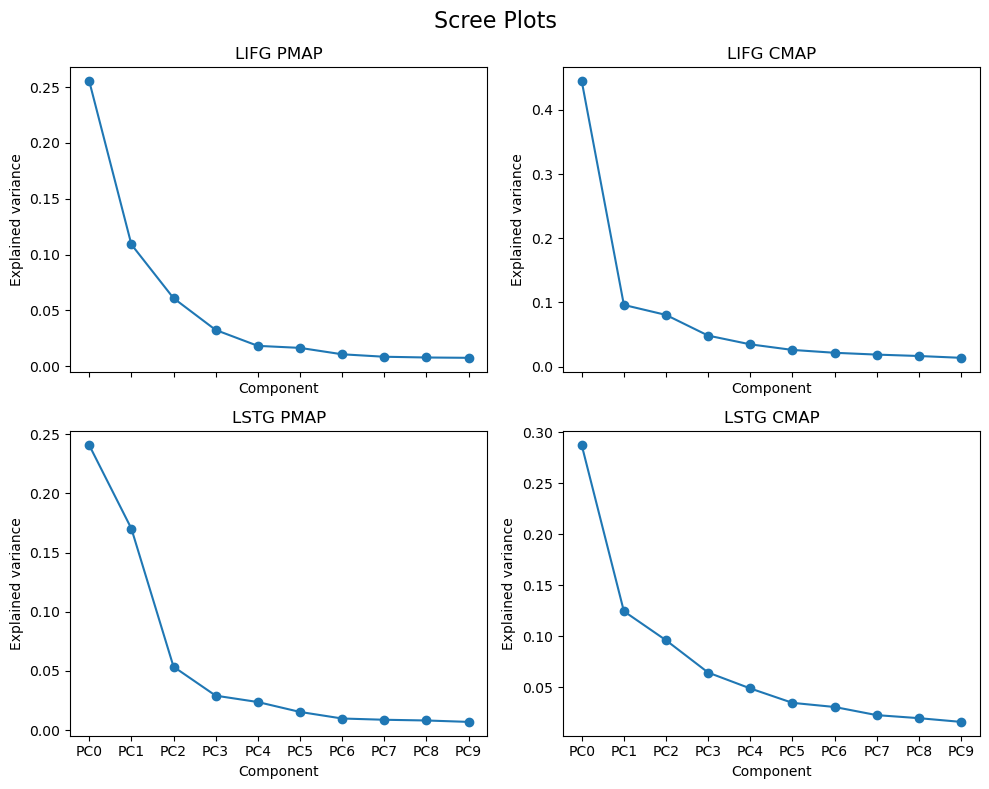

In [2]:
# make scree plot

windows = True

if windows:
    base_path = "P:/workspaces/lg-ukbiobank/projects/CONGRADS_rest/"
else:
    base_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/"

afd = pd.read_csv(os.path.join(base_path, "all_data_lstg_g0_pmap_template_pca_expl_var.tsv"), sep="\t", index_col=0)
stl = pd.read_csv(os.path.join(base_path, "all_data_lstg_g0_cmap_template_pca_expl_var.tsv"), sep="\t", index_col=0)
tbm = pd.read_csv(os.path.join(base_path, "all_data_lifg_g0_pmap_template_pca_expl_var.tsv"), sep="\t", index_col=0)
ifl = pd.read_csv(os.path.join(base_path, "all_data_lifg_g0_cmap_template_pca_expl_var.tsv"), sep="\t", index_col=0)

data = pd.concat([tbm, ifl, afd, stl], axis=1)
data.columns = ['LIFG PMAP', 'LIFG CMAP', 'LSTG PMAP', 'LSTG CMAP']

# Make a 2x2 subplots with scree plots for each row of data
def make_scree(data):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    fig.suptitle('Scree Plots', fontsize=16)

    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            ax.plot(data.iloc[:, i*2+j], marker='o')
            ax.set_title(f'{data.columns[i*2+j]}')
            ax.set_xlabel('Component')
            ax.set_ylabel('Explained variance')

    plt.tight_layout()
make_scree(data)

plt.savefig(os.path.join(base_path, "results", "Supp_scree_plots.png"), dpi=300, bbox_inches='tight')